**Libraries**

In [97]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

**Original Dataset**

In [98]:
# data = pd.read_stata('/workspaces/malnutrition/NPKR82FL.DTA')
# data.head()

In [99]:
data = pd.read_stata('NPKR82FL.DTA')
data.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,s604c,s607ea,s607eb,s607ec,s607ed,s607ex,s607f,s607g,s615f,s631o
0,1 1 2,1,NP8,1,1,2,1,916093,magh,2078,...,no,no,no,no,no,no,no,no,NaN,NaN
1,1 8 2,1,NP8,1,8,2,1,916093,magh,2078,...,no,no,yes,no,no,no,NaN,no,NaN,no
2,1 8 2,2,NP8,1,8,2,1,916093,magh,2078,...,NaN,no,yes,no,no,no,NaN,no,NaN,no
3,1 9 3,1,NP8,1,9,3,1,916093,magh,2078,...,no,no,no,no,no,no,yes,no,NaN,no
4,1 19 1,1,NP8,1,19,1,1,916093,magh,2078,...,no,yes,yes,no,no,no,NaN,no,NaN,NaN


In [100]:
data.shape

(5372, 1422)

**Selected Features**

In [101]:
df1 = data.copy()
df1 = df1[['b19', 'v106', 'v525', 'v228', 'v190', 'v102', 'v101', 'v445', 'b11', 'v137', 'v208', 'v130', 'v131', 'm19', 'b4', 'm4', 'v012', 'v212', 'v729', 'v714', 'v481',  'hw71', 'hw70', 'hw72']]
df1.rename(columns={'b19': 'Child_age', 'v106':'Mother_education', 'v525': 'Age_first_sex', 'v228': 'Pregnancy_terminated', 'v190':'Wealth_index', 'v102':'Place_residence', 'v101':'Region', 'v445':'BMI', 'b11':'Birth_interval', 'v137':'Children_under5', 'v208': 'Total_children_ever_born', 'v130':'Religion', 'v131':'Ethnicity', 'm19':'Birth_weight', 'b4':'Child_sex', 'm4':'Breastfeeding_duration', 'v012':'Mother_age_current', 'v212': 'Mother_age_at_first_birth', 'v729':'Father_education', 'v714':'Mother_working', 'v481':'Health_insurance',  'hw71':'Underweight', 'hw70':'Stunting',  'hw72':'Wasting'}, inplace=True)
df1.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,36.0,1,...,female,NaN,29,17,complete primary,yes,no,NaN,NaN,NaN
1,28,basic,29.0,no,poorest,rural,koshi,NaN,13.0,2,...,female,still breastfeeding,33,30,incomplete primary,no,no,NaN,NaN,NaN
2,42,basic,29.0,no,poorest,rural,koshi,NaN,NaN,2,...,female,NaN,33,30,incomplete primary,no,no,NaN,NaN,NaN
3,17,basic,14.0,no,poorest,rural,koshi,2200.0,207.0,1,...,female,still breastfeeding,34,16,incomplete secondary,no,no,-65.0,-111.0,-19.0
4,40,secondary,17.0,yes,poorer,rural,koshi,2510.0,19.0,2,...,male,NaN,26,21,complete primary,yes,no,-185.0,-311.0,-7.0


*24 features are selected out of 1422 features on the basis of existing litreture, which are:*

'Child_age', 'Mother_education', 'Age_first_sex', 'Pregnancy_terminated', 'Wealth_index', 'Place_residence', 'Region', 'BMI', 'Birth_interval', 'Children_under5', 'Total_children_ever_born','Religion', 'Ethnicity', 'Birth_weight', 'Child_sex', 'Breastfeeding_duration', 'Mother_age_current', 'Mother_age_at_first_birth', 'Father_education', 'Mother_working', 'Health_insurance', 'Underweight', 'Stunting', 'Wasting'

In [102]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Child_age                  5372 non-null   int8    
 1   Mother_education           5372 non-null   category
 2   Age_first_sex              5371 non-null   category
 3   Pregnancy_terminated       5372 non-null   category
 4   Wealth_index               5372 non-null   category
 5   Place_residence            5372 non-null   category
 6   Region                     5372 non-null   category
 7   BMI                        2736 non-null   category
 8   Birth_interval             3172 non-null   float64 
 9   Children_under5            5372 non-null   int8    
 10  Total_children_ever_born   5372 non-null   category
 11  Religion                   5372 non-null   category
 12  Ethnicity                  5372 non-null   category
 13  Birth_weight               3177 n

In [103]:
# df1.loc[1369, 'Ethnicity']

In [104]:
df2 = df1.copy()
df2.drop(index = 3251, inplace=True) # BMI 9998.0
df2.drop(index = [658,730, 4417], inplace = True) # Religion 96
df2.drop(index = [1369, 602, 603], inplace=True) # Ethnicity 96
df2 = df2[~df2['Birth_weight'].isin(['not weighed at birth', "don't know"])] # Birth_weight 9998 or 9996
df2 = df2[~df2['Father_education'].isin(["don't know"])]
df2 = df2[~df2['Underweight'].isin(['flagged cases'])]
df2 = df2[~df2['Wasting'].isin(['height out of plausible limits', 'flagged cases'])] # Wasting 9998 or 9996
df2 = df2[~df2['Stunting'].isin(['flagged cases'])]

df2['Religion'] = df2['Religion'].cat.remove_unused_categories()
df2['Ethnicity'] = df2['Ethnicity'].cat.remove_unused_categories()

In [105]:
df2.shape

(4636, 24)

In [106]:
df2 = df2.dropna(subset=['Underweight', 'Stunting', 'Wasting'])

In [107]:
df2.isnull().sum()

Child_age                       0
Mother_education                0
Age_first_sex                   1
Pregnancy_terminated            0
Wealth_index                    0
Place_residence                 0
Region                          0
BMI                             0
Birth_interval                966
Children_under5                 0
Total_children_ever_born        0
Religion                        0
Ethnicity                       0
Birth_weight                 1025
Child_sex                       0
Breastfeeding_duration       1025
Mother_age_current              0
Mother_age_at_first_birth       0
Father_education               24
Mother_working                  0
Health_insurance                0
Underweight                     0
Stunting                        0
Wasting                         0
dtype: int64

In [110]:
df2['Malnourished'] = df2[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df2 = df2.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df2.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Ethnicity,Birth_weight,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Malnourished
3,17,basic,14.0,no,poorest,rural,koshi,2200.0,207.0,1,...,hill chhetri,3100.0,female,still breastfeeding,34,16,incomplete secondary,no,no,-19.0
4,40,secondary,17.0,yes,poorer,rural,koshi,2510.0,19.0,2,...,hill janajati,NaN,male,NaN,26,21,complete primary,yes,no,-7.0
5,59,secondary,17.0,yes,poorer,rural,koshi,2510.0,NaN,2,...,hill janajati,NaN,female,NaN,26,21,complete primary,yes,no,21.0
11,55,secondary,17.0,no,poorer,rural,koshi,2153.0,44.0,1,...,hill janajati,NaN,female,NaN,28,18,incomplete primary,yes,no,-96.0
14,14,basic,16.0,no,poorest,rural,koshi,2803.0,98.0,1,...,hill janajati,3500.0,male,still breastfeeding,26,16,no education,yes,no,1.0


**Numeric Features**

In [112]:
numeric_cols = ['Child_age', 'BMI', 'Birth_interval', 'Age_first_sex', 'Birth_weight', 'Mother_age_current', 'Mother_age_at_first_birth', 'Children_under5', 'Total_children_ever_born', 'Malnourished']
df2[numeric_cols] = df2[numeric_cols].apply(pd.to_numeric, errors = 'coerce')

**WHO reference standard**

In [115]:
df2['BMI'] = df2['BMI']/100
df2["Malnourished"] = df2["Malnourished"]/100
# df2['Stunting'] = df2["Stunting"]/100
# df2['Wasting'] = df2["Wasting"]/100

# df2['Underweight'] = [0 if -2 <= val <= 2 else 1 for val in df2['Underweight']] # Weight-for-Age (WAZ) → Underweight
# df2['Stunting'] = [0 if -2 <= val <= 2 else 1 for val in df2['Stunting']] # Height-for-Age (HAZ) → Stunting
df2['Malnourished'] = [0 if -2 <= val <= 2 else 1 for val in df2['Malnourished']] # Weight-for-Height (WHZ) → Wasting

**Z-score Concept (Standard Deviation Score)**

Malnutrition classification is based on how far a child’s anthropometric measurement deviates from the WHO reference standard for children of the same age and sex. This deviation is quantified using the *Z-score*, also known as the *standard deviation score*.

A Z-score tells you how many standard deviations (SDs) a measurement is from the reference population median.

$$Z = \frac{(X - \mu)}{\sigma}$$

Where,
- $X$ = Observed measurement (e.g. child’s weight or height)
- $\mu$ = Median of the reference population (matched by age and sex)
- $\sigma$ = Standard deviation of the reference population

## Feature Importance Check for Numerical Features

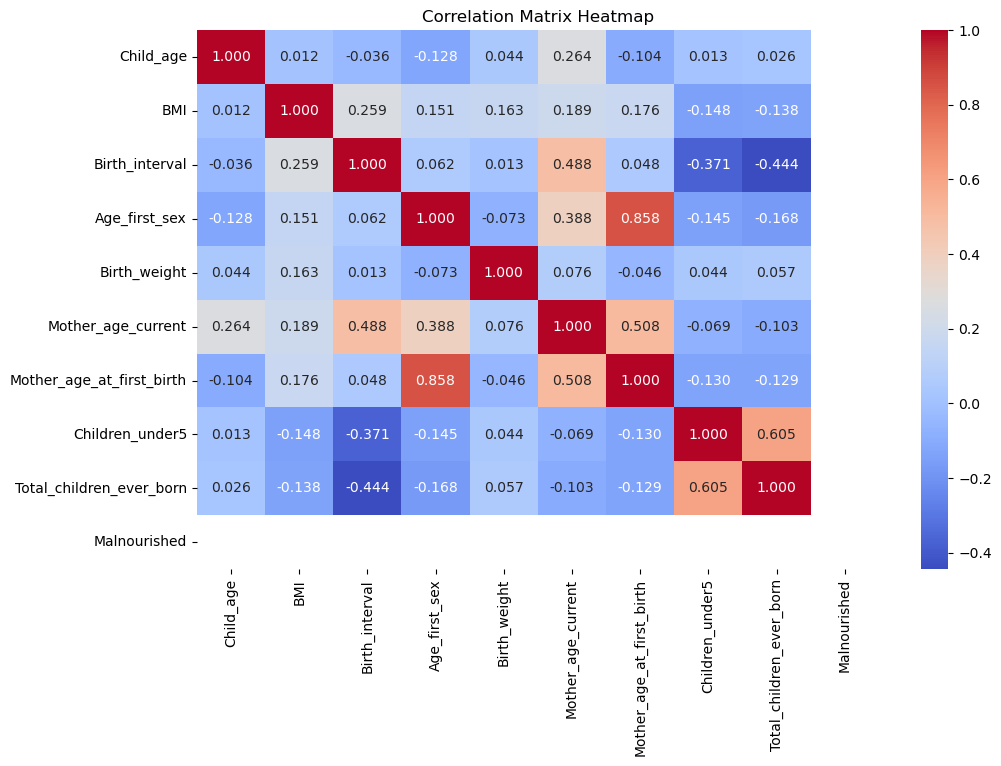

In [117]:
# Create a heatmap
correlation_matrix = df2[numeric_cols].corr()

plt.figure(figsize=(11, 7))  # Set figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Matrix Heatmap")
plt.show()

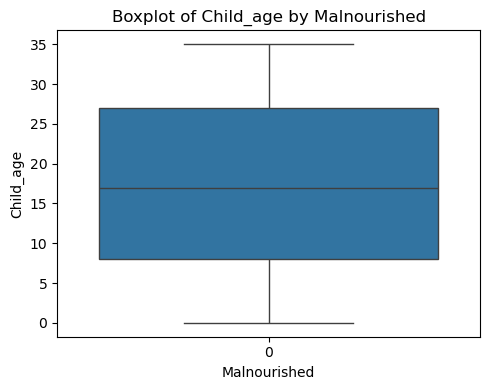

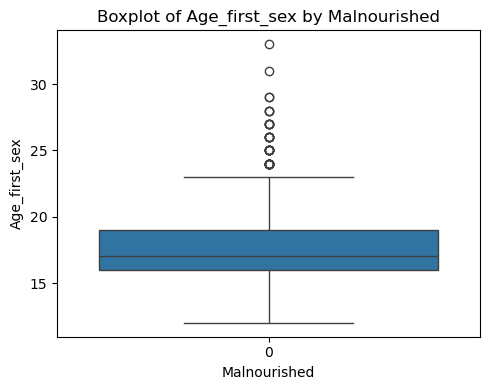

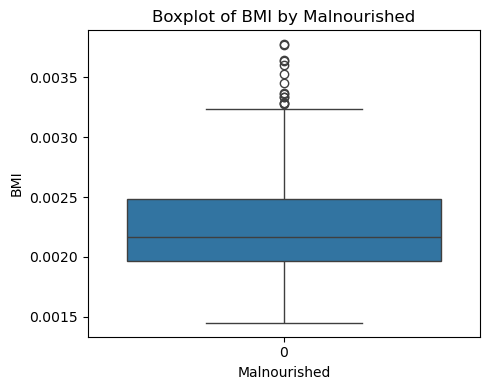

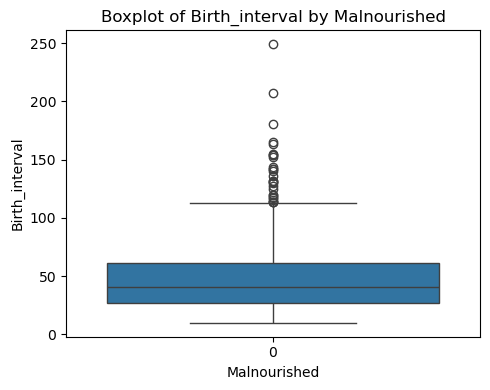

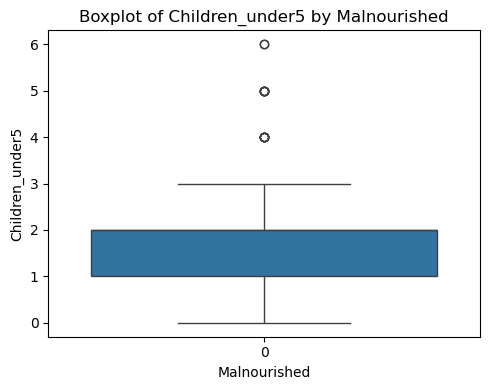

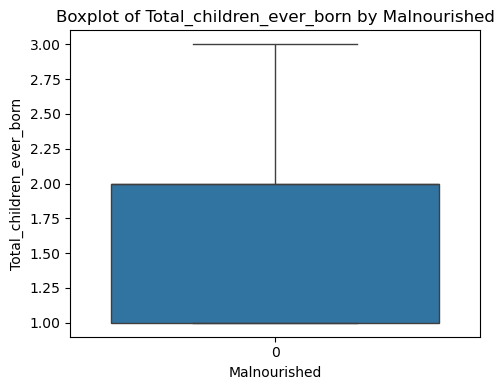

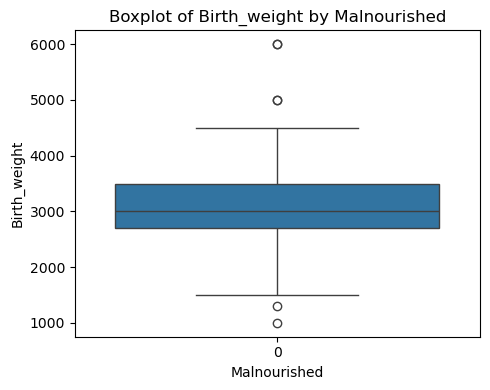

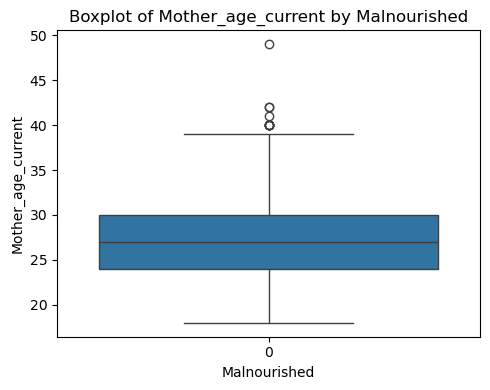

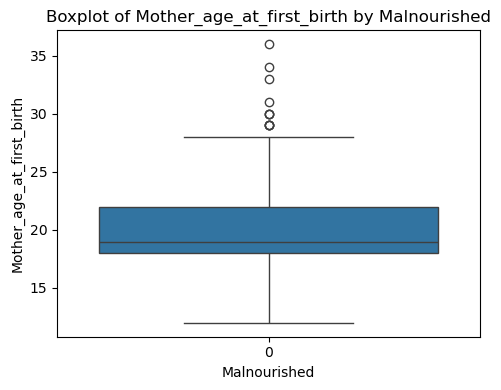

In [124]:

# Loop through each numeric column (excluding 'Underweight' itself)
for col in numeric_cols:
    if col not in ['Malnourished']:  
        plt.figure(figsize=(5, 4))
        sns.boxplot(x='Malnourished', y=col, data=df2)
        plt.title(f'Boxplot of {col} by Malnourished')
        plt.xlabel('Malnourished')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


- Age_first_sex and Mother_age_at_first_birth look multicolinear also they are not singnificantly associated with response variable so Age_first_sex is removed.
- Mother_age_at_first_birth and Mother_age_current are multicolinear and not closly associated with response variable so Mother_age_at_first_birth

## Feature Importance Check for Categorical Features

### $\chi^2$ Test

In [ ]:
# Listing all categorical features
cat_cols = ['Mother_education', 'Pregnancy_terminated', 'Wealth_index', 'Place_residence', 'Region', 'Religion', 'Ethnicity', 'Child_sex', 'Breastfeeding_duration', 'Father_education', 'Mother_working',
       'Health_insurance']

In [ ]:
# Contingency Table
for col in cat_cols:
    contingency_table = pd.crosstab(df2[col], df2['Underweight'])
    print(f"Contingency Table: {col} vs Underweight\n")
    print(contingency_table)
    print("\n" + "-"*50 + "\n")


In [ ]:
from scipy.stats import chi2_contingency

# Dictionary to store test results
chi2_results = {}

for col in cat_cols:
    # Create contingency table
    contingency_table = pd.crosstab(df2[col], df2['Underweight'])

    # Perform Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Store the results
    chi2_results[col] = {
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Degrees of Freedom': dof
    }

    # Print summary
    print(f"{col}: Chi2 = {chi2:.2f}, p = {p:.4f}, dof = {dof}")


### Cramers V Test

$$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$$


In [ ]:
from scipy.stats import chi2_contingency

cramers_v_results = {}

for col in cat_cols:
    if col != 'Underweight':
        # Contingency table
        table = pd.crosstab(df2[col], df2['Underweight'])

        # Chi-squared test
        chi2, _, _, _ = chi2_contingency(table)

        # Total sample size
        n = table.sum().sum()

        # Phi-squared
        phi2 = chi2 / n

        # Degrees of freedom: min(k - 1, r - 1)
        r, k = table.shape
        dof = min(k - 1, r - 1)

        # Cramér's V
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        print(f"{col}: Cramér's V = {V:.4f}")


Only Mother_education, Region, and Ethnicity show weak association with Underweight. All other variables have negligible association, based on Cramér’s V.

**Cramér’s V Bar Plot**

In [ ]:
# Cramér's V results
cramers_v = {
    'Mother_education': 0.1239,
    'Pregnancy_terminated': 0.0087,
    'Wealth_index': 0.0565,
    'Place_residence': 0.0341,
    'Region': 0.1285,
    'Religion': 0.0663,
    'Ethnicity': 0.1526,
    'Child_sex': 0.0364,
    'Breastfeeding_duration': 0.0537,
    'Father_education': 0.0774,
    'Mother_working': 0.0049,
    'Health_insurance': 0.0458
}

# Sort the dictionary by values (descending)
cramers_v_sorted = dict(sorted(cramers_v.items(), key=lambda item: item[1], reverse=True))

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(
    list(cramers_v_sorted.keys()),
    list(cramers_v_sorted.values()),
    color='orange'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', va='center')

# Aesthetics
plt.xlabel("Cramér's V")
plt.title("Cramér's V for Categorical Variables vs Underweight")
plt.gca().invert_yaxis()  # Highest V at the top
plt.tight_layout()
plt.show()


In [ ]:
df3 = df2.drop(columns=['Age_first_sex', 'Mother_age_at_first_birth', 'Mother_working', 'Pregnancy_terminated', 'Breastfeeding_duration', 'Birth_interval', 'Birth_weight'])

In [ ]:
df3.isna().sum()

In [ ]:
df3 = df3.dropna()

In [ ]:
df3.shape

In [ ]:
ordinal_mappings = {
    'Mother_education': {
        'no education': 0,
        'basic': 1,
        'secondary': 2,
        'higher': 3
    },
    'Wealth_index': {
        'poorest': 0,
        'poorer': 1,
        'middle': 2,
        'richer': 3,
        'richest': 4
    },
    'Father_education': {
        'no education': 0,
        'incomplete primary': 1,
        'complete primary': 1,
        'incomplete secondary': 2,
        'complete secondary': 2,
        'higher': 3
    }
}

for col, mapping in ordinal_mappings.items():
    df3[col] = df3[col].map(mapping)

In [ ]:
df4 = pd.get_dummies(df3, columns=['Mother_education', 'Wealth_index', 'Place_residence', 'Region', 'Religion', 'Ethnicity', 'Child_sex', 'Father_education', 'Health_insurance'], drop_first=True)
df4 = df4.astype({col: int for col in df4.select_dtypes('bool').columns})
df4.head()

In [ ]:
df4.info()

### Variance Inflation Factor Check

In [ ]:
X = add_constant(df4)

# Calculate VIF for each variable
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

inf indicates the perfect multicolinearity between Religion_muslim and Ethnicity_muslim. There is no Ethnicity_muslim, it may be due to record error. We will remove Ethnicity_muslim from the dataframe.

In [ ]:
df = df4.drop(columns=['Ethnicity_muslim'])
df.info()

In [ ]:
# df.to_csv("//workspaces/malnutrition/Methods/df.csv", index=False)